#**KYC Onboarding & Risk Adjudication System**

This project is a programmed framework designed to automate the initial onboarding of banking customers under the Bank Secrecy Act (BSA) and the USA PATRIOT Act.

The system demonstrates a Risk-Based Approach (RBA) by processing raw applicant data, conducting automated screening against Sanctions, high-risk jurisdictions and PEP lists, and assigning a final Risk Rating. It ensures that the institution focuses its human resources on High-Risk cases while streamlining the entry of Low-Risk customers.

##**OBJECTIVES:**

*   **Regulatory Compliance:** Implement Customer Identification Program (CIP) and Customer Due Diligence (CDD) requirements;
*   **Automated Risk Scoring:** Develop an objective weighted algorithm to classify customers into Low, Medium, and High risk;
*   **Automated Mandatory Adjudication:** Ensure 100% rejection for Sanction matches and mandatory Enhanced Due Diligence (EDD) for Politically Exposed Persons (PEPs) and high-risk jurisdictions.
*   **Operational Efficiency:** Segment applicants based on the required level of diligence (SDD, CDD, or EDD).

##**Regulatory Frameworks:**

This system is engineered to comply with the United States regulatory landscape while maintaining alignment with global Financial Action Task Force (FATF/GAFI) recommendations. The architecture integrates robust mechanisms for identity verification and risk management as mandated by federal and international standards.

### Primary Federal Regulations:

*   **Bank Secrecy Act (BSA):** The system focuses on the "Customer Identification Program" (CIP) and "Customer Due Diligence" (CDD) pillars. It automates the initial screening process to prevent the placement of illicit funds by ensuring that high-risk individuals are identified before an account is established.
*   **USA PATRIOT Act:** In accordance with Title III, the system incorporates a Customer Identification Program (CIP) to verify the identity of every person seeking to open an account.
*   **Anti-Money Laundering Act of 2020 (AMLA):** The system is built to support the latest reporting standards and beneficial ownership transparency requirements established by the AMLA.

### KYC & Due Diligence Implementation:
The system follows a Risk-Based Approach (RBA), categorizing users into different verification tiers:

*   **Simplified Due Diligence (SDD):** Applied to low-risk entities, utilizing streamlined verification processes.
*   **Customer Due Diligence (CDD):** The standard protocol for verifying identity, understanding the nature of the business relationship, and identifying the Ultimate Beneficial Owner (UBO).
*   **Enhanced Due Diligence (EDD):** Automated triggers for high-risk profiles, such as Politically Exposed Persons (PEPs) or high-risk jurisdictions, requiring additional documentation and source-of-wealth verification.

## **Methodology and Scope**:
The project follows a 3-step data pipeline:

**1) Data Ingestion (The Onboarding Batch)**:

The system processes 1,000 synthetic applicants (Individuals and Companies) with the following attributes:


*   **applicant_id:** A unique internal identifier used for database indexing and maintaining a clear audit trail for each onboarding request;
*   **full_name:** The legal name of the applicant or entity (We did not use faker to simulate the names);
*   **entity_type:** Segregates 'Individual' and 'Company' profiles. This is crucial for applying the correct verification standards, as corporate entities require additional Beneficial Ownership (UBO) documentation;
*   **tax_id:** The primary government-issued identifier (SSN or EIN). Essential for identity cross-referencing and ensuring the applicant is a legitimate taxpayer;
*   **residency:** The country of current operations or living. It is a primary factor in the Geopolitical Risk score, especially for jurisdictions with high levels of corruption or terrorism financing;
*   **nationality:** The applicant's legal citizenship. Monitored to prevent Sanctions evasion, particularly when an applicant resides in a low-risk country but holds high-risk citizenship;
*   **dob_incorp_date:** Date of birth or incorporation. Used to verify the applicant's age (minimum legal requirements) or the "age" of a company to detect potential "shell companies";
*   **annual_income:** Reported yearly earnings. Serves as the baseline for the Source of Wealth (SoW) analysis and transaction monitoring thresholds;
*   **net_worth:** Total estimated assets. When compared with annual_income, it triggers alerts if there is a disproportionate wealth-to-income ratio;
*   **occupation_industry:** Integrated as a risk-weighting factor; industries like 'Casino/Gambling' or 'Crypto Services' are flagged due to high cash-intensity and money laundering vulnerability;
*   **is_sanctioned:** The most critical risk flag. A positive match (1) indicates the entity is on a prohibited list (e.g., OFAC), triggering an automatic REJECTION of the account;
*   **is_pep (Politically Exposed Person):** A critical boolean flag that bypasses standard scoring to mandate Enhanced Due Diligence (EDD), ensuring compliance with high-level oversight requirements;
*   **device_id & ip_address:** Essential for Digital Fingerprinting. This allows the detection of "Money Mule" networks by identifying multiple distinct applicants sharing the same hardware or network access points;
*   **email:** Contact information used for verification and as a secondary data point for identity consistency checks.



**2) The Risk Scoring Engine:**

Weights are applied based on the following risk factors:

*   **Sanctions Check:** 100 points (Immediate Rejection);
*   **PEP Status:** 50 points + Mandatory EDD Trigger;
*   **Jurisdictional Risk:** 45 points for countries with high AML deficiencies;
*   **Industry Risk:** 20 points for cash-intensive businesses (Casinos, Pawn Shops);
*   **Income and Networth mismatch:** +15 points for applicants whose Networth is more than 10 times higher than their annual income.




**3) Adjudication & Diligence Logic:**

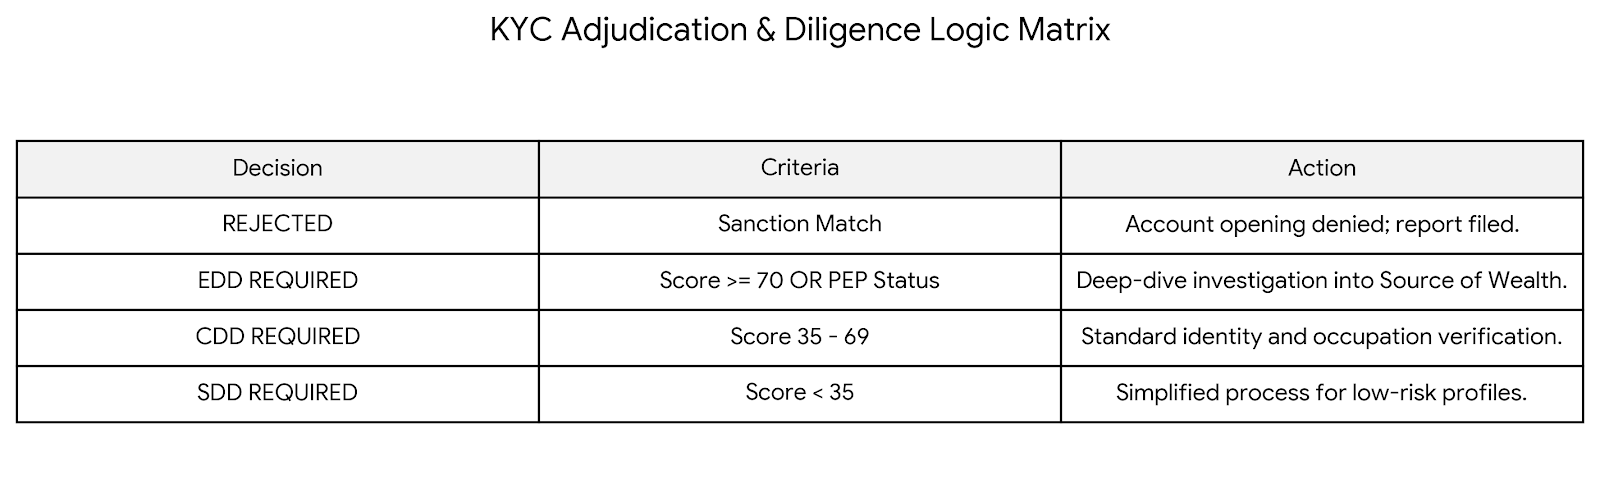



In [27]:
import pandas as pd
import numpy as np
import random
import sqlite3
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

# --- 1. SETUP & DATA GENERATION ---
conn = sqlite3.connect('kyc_onboarding.db')
NUM_APPLICANTS = 1000

# Regulatory Segmentation
sanctioned_countries = ['North Korea', 'Iran', 'Russia', 'Syria'] # Mandatory Rejection
fatf_high_risk = ['Cayman Islands', 'Panama', 'Nigeria', 'Myanmar'] # FATF Grey list (High Risk)
industries = ['Technology', 'Healthcare', 'Retail', 'Casino/Gambling', 'Pawn Shop', 'Real Estate', 'Crypto Services']

pep_names = [f"Customer_{random.randint(1, 1000)}" for _ in range(15)]
sanction_names = [f"Customer_{random.randint(1, 1000)}" for _ in range(5)]

applicants = []

for i in range(1, NUM_APPLICANTS + 1):
    entity = random.choice(['Individual', 'Company'])
    name = f"Customer_{i}" if entity == 'Individual' else f"Entity_Corp_{i}"

    tax_id = f"{random.randint(100,999)}-{random.randint(10,99)}-{random.randint(1000,9999)}" if entity == 'Individual' else f"{random.randint(10,99)}-{random.randint(1000000,9999999)}"

    # Geography Logic
    rand_geo = random.random()
    if rand_geo < 0.85:
        residency = 'USA'
    elif rand_geo < 0.92:
        residency = random.choice(fatf_high_risk) # High Risk Jurisdictions
    elif rand_geo < 0.95:
        residency = random.choice(sanctioned_countries) # Sanctioned Countries
    else:
        residency = random.choice(['Canada', 'UK', 'Brazil', 'France'])

    nationality = 'USA' if random.random() < 0.95 else random.choice(['Brazil', 'Mexico', 'France', 'China'])

    tier_rand = random.random()
    if tier_rand < 0.60: income = random.randint(15000, 36000)
    elif tier_rand < 0.90: income = random.randint(36001, 120000)
    else: income = random.randint(120001, 500000)

    applicants.append({
        'applicant_id': i,
        'full_name': name,
        'entity_type': entity,
        'tax_id': tax_id,
        'residency': residency,
        'nationality': nationality,
        'occupation_industry': random.choice(industries),
        'dob_incorp_date': (datetime.now() - timedelta(days=random.randint(7000, 20000))).date(),
        'annual_income': income,
        'net_worth': income * random.randint(2, 12),
        'is_pep': 1 if name in pep_names else 0,
        'is_sanctioned_list': 1 if name in sanction_names else 0, # Match by Name
        'ip_address': f"{random.randint(1,255)}.{random.randint(1,255)}.{random.randint(1,255)}.{random.randint(1,255)}",
        'device_id': f"DEV-{random.randint(1000,9999)}",
        'email': f"{name.lower()}@example.com"
    })

df = pd.DataFrame(applicants)

# --- 2. ADJUDICATION LOGIC (Refined) ---
def adjudicate_kyc(row):
    score = 0
    high_risk_industries = ['Casino/Gambling', 'Pawn Shop', 'Crypto Services']

    # 1. Sanction Check (Immediate Rejection)
    # Rejects if name is in list OR if residency is a sanctioned country
    if row['is_sanctioned_list'] == 1 or row['residency'] in sanctioned_countries:
        return 100, "REJECTED", "Account Opening Denied - Sanction Match (Name or Geography)"

    # 2. Risk Score Building
    if row['is_pep'] == 1: score += 50
    if row['residency'] in fatf_high_risk or row['nationality'] in fatf_high_risk: score += 45
    if row['occupation_industry'] in high_risk_industries: score += 20

    # Wealth Mismatch Check
    if row['net_worth'] > 400000 and row['annual_income'] < 40000: score += 15

    score = min(score, 100)

    # Determine Rating
    if score >= 70: rating = "High"
    elif score >= 35: rating = "Medium"
    else: rating = "Low"

    # 3. Diligence Determination
    # EDD is mandatory for PEPs, FATF High-Risk countries, or High Scores
    if row['is_pep'] == 1 or rating == "High" or row['residency'] in fatf_high_risk:
        diligence = "Enhanced Due Diligence (EDD) Required"
    elif rating == "Medium":
        diligence = "Customer Due Diligence (CDD)"
    else:
        diligence = "Simplified Due Diligence (SDD)"

    return score, rating, diligence

df[['risk_score', 'risk_rating', 'required_diligence']] = df.apply(
    lambda row: pd.Series(adjudicate_kyc(row)), axis=1
)

# --- 3. FINAL RESULTS ---
df.to_sql('adjudicated_applicants', conn, index=False, if_exists='replace')

print("--- ADJUDICATION SUMMARY ---")
print(df['required_diligence'].value_counts())
if "REJECTED" in df['required_diligence'].values:
    print(f"Total Rejections: {len(df[df['risk_score'] == 100])}")

--- ADJUDICATION SUMMARY ---
required_diligence
Simplified Due Diligence (SDD)                                 904
Enhanced Due Diligence (EDD) Required                           65
Account Opening Denied - Sanction Match (Name or Geography)     28
Customer Due Diligence (CDD)                                     3
Name: count, dtype: int64


#**System Capability Showcase:**

After processing the 1,000-applicant dataset, the system allows for targeted queries to identify specific risk patterns. Below are three examples of automated red-flag detection:

##1) Fraud Detection: Digital Footprint Fingerprinting

In [28]:
# Find devices associated with multiple accounts
device_sharing = df['device_id'].value_counts()
shared_devices = device_sharing[device_sharing > 1]
print(shared_devices.head(20))

device_id
DEV-1745    3
DEV-4268    3
DEV-5945    2
DEV-7188    2
DEV-3827    2
DEV-5832    2
DEV-8111    2
DEV-1797    2
DEV-6224    2
DEV-2785    2
DEV-7275    2
DEV-9115    2
DEV-5487    2
DEV-5999    2
DEV-3664    2
DEV-6921    2
DEV-5967    2
DEV-2702    2
DEV-8935    2
DEV-5781    2
Name: count, dtype: int64


###**Risk Alert Analysis: Digital Fingerprinting (Device Sharing)**.
The data extraction revealed 64 devices associated with multiple accounts. In a digital banking onboarding environment, overlapping hardware identifiers (device_id) without a clear household or commercial justification is a critical red flag for system abuse.

**Risk Vectors & Regulatory Implications:**

*   **Indications of "Structuring" and "Smurfing":**

This pattern suggests the fragmentation of capital across multiple accounts operated from a single terminal. By distributing funds, bad actors attempt to remain below transaction monitoring thresholds—such as the $10,000 CTR (Currency Transaction Report) threshold mandated by the Bank Secrecy Act (BSA)—to evade automated detection.

*   **Money Mule Networks (Centralized Control):**

The concentration of distinct Tax IDs/SSNs on a single physical device indicates Centralized Operator Control. In AML/CTF investigations, this is a classic signature of a "Mule Network," where a coordinator manages accounts to obscure the Ultimate Beneficial Owner (UBO).

*   **Sybil Attacks & Synthetic Identity Fraud:**

Repetitive hardware signatures often point to Sybil Attacks. Fraudsters utilize synthetic identities in bulk to test onboarding controls, bypass velocity limits, or conduct large-scale promotional abuse.

###**Recommended Actions:**

*   **Escalate for EDD:** Apply Enhanced Due Diligence to all accounts linked to these devices to verify: *(a) Relationship Linkage; (b) Source of Wealth(SoW)* and; *(b)Liveness Check*.

*   **Restrict Activity:** Place a temporary Post No Debit (PND) hold on high-risk clusters until the analysis is substantiated.

*   **Holistic Investigation:** Conduct a cross-account linkage analysis to identify the primary controller of the hardware.

##2) Geographic "Heat" Mapping (Jurisdictional Risk)

In [29]:
# Identifying Total Rejections (Sanctioned Jurisdictions)
sanction_rejections = df[df['risk_score'] == 100]

# Identifying 'Concentration Risk' in FATF High-Risk Jurisdictions

fatf_risk_cluster = df[
    (df['residency'].isin(fatf_high_risk)) |
    (df['nationality'].isin(fatf_high_risk))
]

print(f"GEOGRAPHIC RISK REPORT")
print(f"Mandatory Sanction Rejections: {len(sanction_rejections)}")
print(f"Applicants in FATF High-Risk Zones (EDD Required): {len(fatf_risk_cluster)}")

print("\n--- TOP 10 HIGH-RISK CONCENTRATION (FATF ZONES) ---")
# Showing specific columns to prove data-driven analysis
print(fatf_risk_cluster[['residency', 'nationality', 'required_diligence']].head(10))

GEOGRAPHIC RISK REPORT
Mandatory Sanction Rejections: 28
Applicants in FATF High-Risk Zones (EDD Required): 61

--- TOP 10 HIGH-RISK CONCENTRATION (FATF ZONES) ---
          residency nationality                     required_diligence
21           Panama         USA  Enhanced Due Diligence (EDD) Required
26   Cayman Islands         USA  Enhanced Due Diligence (EDD) Required
78          Myanmar      France  Enhanced Due Diligence (EDD) Required
82   Cayman Islands         USA  Enhanced Due Diligence (EDD) Required
89           Panama         USA  Enhanced Due Diligence (EDD) Required
113  Cayman Islands         USA  Enhanced Due Diligence (EDD) Required
130          Panama         USA  Enhanced Due Diligence (EDD) Required
164         Myanmar         USA  Enhanced Due Diligence (EDD) Required
168          Panama         USA  Enhanced Due Diligence (EDD) Required
170         Myanmar      Mexico  Enhanced Due Diligence (EDD) Required


###**Risk Alert Analysis: Jurisdictional Concentration Risk.**
The data extraction identified 28 Mandatory Sanction Rejections and 61 applicants (Individuals and Legal Entities) linked to High-Risk Jurisdictions — based on residency or nationality. In compliance, this represents Geopolitical Risk, as these territories are frequently subject to international sanctions (OFAC/UN) or identified as having strategic AML deficiencies by the FATF (Financial Action Task Force).

**Risk Vectors & Regulatory Implications:**

*   **Sanctions Risk:**

The presence of applicants from sanctioned territories represents a "Hard Block" scenario or a mandatory escalation to the Sanctions Department to prevent violations of OFAC regulations.
*   **Shell Company Risk:**

A significant number of these applicants are Legal Entities (Corps) based in offshore tax havens. This is a classic indicator of potential Layering, where illicit funds are moved through complex corporate structures to obscure the trail before entering the US financial system.
*   **FATF "Blacklist" and "Grey List" Exposure:**

These profiles automatically triggered a higher risk score in the Python engine, as residency in FATF-listed countries is a primary risk factor in any Risk-Based Approach (RBA).

###**Recommended Actions:**

*   **Mandatory EDD**: In compliance with international AML standards (e.g., FATF Recommendation 19), these accounts must be automatically escalated to Enhanced Due Diligence. Residency in a high-risk jurisdiction is a regulatory trigger that overrides standard onboarding procedures.
*   **Verification of Source of Wealth (SoW):** Require additional documentation to verify how the customer’s total net worth was acquired, ensuring funds are not derived from illicit activities in sanctioned or poorly regulated regions.
*   **Ongoing Monitoring (High-Velocity Alerts):** Implement a "Strict Monitoring" flag on these profiles. Any cross-border transaction involving these accounts should trigger a real-time manual review by the Compliance Unit
*   **Nationality vs. Residency Verification:** Conduct a specific audit to ensure the Residency declared matches the IP Address and Device Geolocation captured at account creation to detect potential "ghost residency" or identity masking.

##3)PEP Exposure:

In [30]:
pep_alerts = df[df['is_pep'] == 1].sort_values(by='net_worth', ascending=False)

print(f"--- PEP ADJUDICATION REPORT ---")
print(f"Total PEPs identified in batch: {len(pep_alerts)}")
print(f"Status: ALL cases moved to Mandatory EDD.")

# Displaying key financial indicators for Source of Wealth (SoW) analysis
if not pep_alerts.empty:
    display(pep_alerts[[
        'full_name',
        'residency',
        'nationality',
        'annual_income',
        'net_worth',
        'risk_score',
        'required_diligence'
    ]])
else:
    print("No PEPs detected in this applicant batch.")

--- PEP ADJUDICATION REPORT ---
Total PEPs identified in batch: 5
Status: ALL cases moved to Mandatory EDD.


,full_name,residency,nationality,annual_income,net_worth,risk_score,required_diligence
692,Customer_693,USA,USA,184731,2032041,50,Enhanced Due Diligence (EDD) Required
250,Customer_251,USA,USA,25851,129255,50,Enhanced Due Diligence (EDD) Required
754,Customer_755,USA,USA,54754,109508,70,Enhanced Due Diligence (EDD) Required
281,Customer_282,Syria,USA,26070,104280,100,Account Opening Denied - Sanction Match (Name ...
558,Customer_559,USA,USA,16175,64700,70,Enhanced Due Diligence (EDD) Required


###**Risk Alert Analysis: PEP Exposure & Anti-Corruption Controls**:

The system identified 5 Politically Exposed Persons (PEPs). While being a PEP is not a crime, their position of power necessitates stringent oversight to prevent the laundering of state assets or involvement in bribery schemes, in alignment with FATF Guidance and the Wolfsberg Group standards.

**Risk Vectors & Regulatory Implications:**

*   **Public Corruption & Bribery:** Onboarding a PEP without robust controls increases the risk of violating the Foreign Corrupt Practices Act (FCPA). Regulators view "willful blindness" toward a PEP’s source of wealth as a significant compliance failure.
*   **Ongoing Monitoring Requirements:** A PEP's risk profile requires Continuous Transaction Monitoring to identify deviations from their declared official income.

###**Recommended Actions:**


*   **Mandatory Enhanced Due Diligence (EDD):** Initiate a deep-dive investigation into the Source of Wealth (SoW) and Source of Funds (SoF) to ensure the assets are consistent with the customer’s known legitimate income.

*   **Adverse Media Screening:** Conduct a targeted "Negative News" search specifically looking for allegations of corruption, fraud, or human rights abuses linked to the applicant or their close associates.



# **INTERNAL MEMO: Enhanced Due Diligence (EDD) Review**

**DATE:** MAY, 6, 2026

**SUBJECT:** Onboarding Review – Customer_693 (Politically Exposed Person)

**Risk Rating:** HIGH

**Recommendation:** APPROVE WITH RESTRICTIONS

### **1) Background and Identification:**
The applicant, Customer_693, is applying for a personal checking account. During the automated onboarding process, the system triggered an EDD Requirement due to a Politically Exposed Person (PEP) match. The applicant holds a senior administrative role in a foreign government (High-Risk Jurisdiction). Identity has been verified via a valid foreign passport and a Social Security Number (SSN).

### **2) Wealth and Source of Funds Analysis:**
The applicant reports an annual income of US$185,000, yet a declared net worth exceeding US$2,000,000. This variance constitutes a "Wealth Mismatch" flag. Upon further inquiry, the applicant provided documentation indicating that the surplus funds originated from the sale of a family-owned real estate asset in 2024.

### **3) Negative News and Screening:**
Screening against OFAC and international sanction lists returned NO MATCHES. A search for "Adverse Media" (Negative News) yielded no derogatory information related to bribery, corruption, or financial crime.

### **4) Final Adjudication:**
Despite the PEP status and wealth variance, the Source of Wealth has been reasonably substantiated via real estate documentation. I recommend APPROVAL of the account opening, subject to the following controls:

*   Monthly transaction monitoring with a $10,000 threshold for international wires.
*   Annual KYC refresh


#**Future Enhancements & Scalability.**



*   **API Integration:** In a production environment, I would integrate real-time APIs like Refinitiv or ComplyAdvantage for live Sanctions screening.
*   **Machine Learning:** Future iterations could utilize Random Forest classifiers to predict 'High Risk' profiles based on historical SAR filing patterns.
*   **OCR Implementation:** Adding Tesseract OCR to automatically verify the passports and ID photos uploaded during the onboarding flow.




